# 93 - カスケード検索精度評価（HNSW vs ITQ-LSH）

ArcFace 顔埋め込み (512次元, 約75K faces) に対して、3つの検索手法の精度・速度を比較評価する。

## 比較手法
1. **Brute-force コサイン類似度** — Ground Truth（全件線形探索）
2. **HNSW** (DuckDB vss) — グラフベース近似最近傍
3. **ITQ-LSH カスケード** — ハミング距離で候補選択 → コサイン類似度でリランキング

## 評価指標
- **Recall@K**: Ground Truth の Top-K と一致する割合
- **Precision@K**: 検索結果中の正解割合
- **MRR**: 最初の正解の逆順位の平均
- **mAP**: Average Precision の平均

## クエリ
- terada ラベル付き顔 (person_label='terada') を使用

## 入力
- `data/images.duckdb` (`face_detections` テーブル, model_name='buffalo_l')
- `data/itq_models/*.pkl` (NB92 で学習済みの ITQ モデル)

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from image_vector_poc.search.lsh.itq import ITQLSH
from image_vector_poc.search.lsh.cascade import CascadeSearcher, benchmark_search, print_benchmark_results

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 全顔埋め込みとメタデータを取得
rows = conn.execute("""
    SELECT f.face_id, f.embedding, f.person_label
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
person_labels = [r[2] for r in rows]

# L2正規化
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms

# terada クエリの抽出
terada_mask = np.array([l == "terada" for l in person_labels])
terada_indices = np.where(terada_mask)[0]
query_embeddings = embeddings[terada_indices]
query_face_ids = [face_ids[i] for i in terada_indices]

print(f"Total faces: {len(embeddings):,}")
print(f"Terada queries: {len(query_embeddings)}")
print(f"Embedding dim: {embeddings.shape[1]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total faces: 75,162
Terada queries: 20
Embedding dim: 512


## 1. Brute-force ベースライン（Ground Truth）

In [2]:
TOP_K_VALUES = [1, 5, 10, 20, 50]
MAX_K = max(TOP_K_VALUES)

# Brute-force: 全クエリの Ground Truth top-K を計算
ground_truth = {}
for qi, q_emb in enumerate(query_embeddings):
    sims = embeddings @ q_emb  # cosine similarity (already L2-normed)
    # 自分自身を除外
    sims[terada_indices[qi]] = -1
    top_indices = np.argsort(-sims)[:MAX_K]
    top_scores = sims[top_indices]
    ground_truth[qi] = {
        "indices": top_indices,
        "scores": top_scores,
        "face_ids": [face_ids[i] for i in top_indices],
    }

print(f"Ground truth computed for {len(ground_truth)} queries, top-{MAX_K} each")
# サンプル表示
print(f"\nQuery 0 top-5 scores: {ground_truth[0]['scores'][:5]}")
print(f"Query 0 top-5 labels: {[person_labels[i] for i in ground_truth[0]['indices'][:5]]}")

Ground truth computed for 20 queries, top-50 each

Query 0 top-5 scores: [0.8453516 0.8450283 0.8396251 0.8316516 0.8274543]
Query 0 top-5 labels: ['terada', None, None, None, None]


## 2. HNSW 検索 (DuckDB vss)

In [3]:
import time

# HNSW 検索
hnsw_results = {}
hnsw_times = []

for qi, q_emb in enumerate(query_embeddings):
    q_list = [float(x) for x in q_emb]
    t0 = time.perf_counter()
    result = conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        WHERE f.model_name = 'insightface/buffalo_l'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[512])
        LIMIT {MAX_K}
    """, [q_list]).fetchall()
    elapsed = time.perf_counter() - t0
    hnsw_times.append(elapsed)
    
    hnsw_face_ids = [r[0] for r in result]
    # 自分自身を除外
    hnsw_face_ids = [fid for fid in hnsw_face_ids if fid != query_face_ids[qi]][:MAX_K]
    hnsw_results[qi] = hnsw_face_ids

print(f"HNSW search done: {len(hnsw_results)} queries")
print(f"Mean latency: {np.mean(hnsw_times)*1000:.1f} ms")
print(f"P95 latency: {np.percentile(hnsw_times, 95)*1000:.1f} ms")

HNSW search done: 20 queries
Mean latency: 53.0 ms
P95 latency: 60.2 ms


## 3. ITQ-LSH カスケード検索

候補数をスイープして Recall@K のトレードオフを評価。

In [4]:
CANDIDATE_SIZES = [100, 200, 500, 1000, 2000, 5000]
BIT_COUNTS = [128]  # 128bit ベースライン、NB92のベストも追加可

# NB92 で保存された全モデルを試す
for model_path in sorted(MODEL_DIR.glob("itq_arcface_*bit.pkl")):
    n_bits = int(model_path.stem.split("_")[-1].replace("bit", ""))
    if n_bits not in BIT_COUNTS:
        BIT_COUNTS.append(n_bits)
BIT_COUNTS = sorted(set(BIT_COUNTS))
print(f"Testing bit counts: {BIT_COUNTS}")

cascade_results = {}  # (n_bits, candidates) -> {qi: [face_ids]}

for n_bits in BIT_COUNTS:
    model_path = MODEL_DIR / f"itq_arcface_{n_bits}bit.pkl"
    if not model_path.exists():
        print(f"Skipping {n_bits}bit (model not found)")
        continue
    
    itq = ITQLSH.load(str(model_path))
    searcher = CascadeSearcher(itq)
    searcher.build_index(embeddings, metadata=face_ids, show_progress=False)
    
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        cascade_results[key] = {}
        
        for qi, q_emb in enumerate(query_embeddings):
            result = searcher.search(q_emb, candidates=candidates, top_k=MAX_K)
            result_fids = [m for m in result["metadata"] if m != query_face_ids[qi]][:MAX_K]
            cascade_results[key][qi] = result_fids
    
    print(f"  {n_bits}bit: {len(CANDIDATE_SIZES)} candidate sizes done")

print(f"\nTotal configurations: {len(cascade_results)}")

Testing bit counts: [64, 96, 128, 256]


  64bit: 6 candidate sizes done


  96bit: 6 candidate sizes done


  128bit: 6 candidate sizes done


  256bit: 6 candidate sizes done

Total configurations: 24


## 4. 精度メトリクス計算

In [5]:
def compute_recall_at_k(retrieved_ids, gt_ids, k):
    """Recall@K: GT top-K のうち検索結果 top-K に含まれる割合"""
    gt_set = set(gt_ids[:k])
    ret_set = set(retrieved_ids[:k])
    return len(gt_set & ret_set) / len(gt_set) if gt_set else 0.0

def compute_mrr(retrieved_ids, gt_ids, k=10):
    """MRR: GT top-1 が検索結果のどの位置にあるか"""
    target = gt_ids[0]
    for rank, fid in enumerate(retrieved_ids[:k], 1):
        if fid == target:
            return 1.0 / rank
    return 0.0

def evaluate_method(results_dict, ground_truth, k_values):
    """全クエリでのメトリクス集計"""
    metrics = {}
    for k in k_values:
        recalls = []
        mrrs = []
        for qi in range(len(ground_truth)):
            gt_fids = ground_truth[qi]["face_ids"]
            ret_fids = results_dict[qi]
            recalls.append(compute_recall_at_k(ret_fids, gt_fids, k))
            if k == 10:
                mrrs.append(compute_mrr(ret_fids, gt_fids, k))
        metrics[f"Recall@{k}"] = np.mean(recalls)
        if k == 10:
            metrics["MRR@10"] = np.mean(mrrs)
    return metrics

# HNSW メトリクス
hnsw_metrics = evaluate_method(hnsw_results, ground_truth, TOP_K_VALUES)
print("=== HNSW ===")
for k, v in hnsw_metrics.items():
    print(f"  {k}: {v:.4f}")

# ITQ-LSH カスケードのメトリクス
print("\n=== ITQ-LSH Cascade ===")
cascade_metrics = {}
for (n_bits, candidates), results in cascade_results.items():
    m = evaluate_method(results, ground_truth, TOP_K_VALUES)
    cascade_metrics[(n_bits, candidates)] = m
    print(f"  {n_bits}bit, cand={candidates:5d}: Recall@10={m['Recall@10']:.4f}, MRR@10={m['MRR@10']:.4f}")

=== HNSW ===
  Recall@1: 1.0000
  Recall@5: 1.0000
  Recall@10: 1.0000
  MRR@10: 1.0000
  Recall@20: 1.0000
  Recall@50: 0.9800

=== ITQ-LSH Cascade ===
  64bit, cand=  100: Recall@10=0.6850, MRR@10=0.7500
  64bit, cand=  200: Recall@10=0.9450, MRR@10=0.9500
  64bit, cand=  500: Recall@10=1.0000, MRR@10=1.0000
  64bit, cand= 1000: Recall@10=1.0000, MRR@10=1.0000
  64bit, cand= 2000: Recall@10=1.0000, MRR@10=1.0000
  64bit, cand= 5000: Recall@10=1.0000, MRR@10=1.0000
  96bit, cand=  100: Recall@10=0.8150, MRR@10=0.6500
  96bit, cand=  200: Recall@10=0.9750, MRR@10=0.9000
  96bit, cand=  500: Recall@10=1.0000, MRR@10=1.0000
  96bit, cand= 1000: Recall@10=1.0000, MRR@10=1.0000
  96bit, cand= 2000: Recall@10=1.0000, MRR@10=1.0000
  96bit, cand= 5000: Recall@10=1.0000, MRR@10=1.0000
  128bit, cand=  100: Recall@10=0.8350, MRR@10=0.8000
  128bit, cand=  200: Recall@10=0.9650, MRR@10=1.0000
  128bit, cand=  500: Recall@10=1.0000, MRR@10=1.0000
  128bit, cand= 1000: Recall@10=1.0000, MRR@10=1.

## 5. 比較可視化

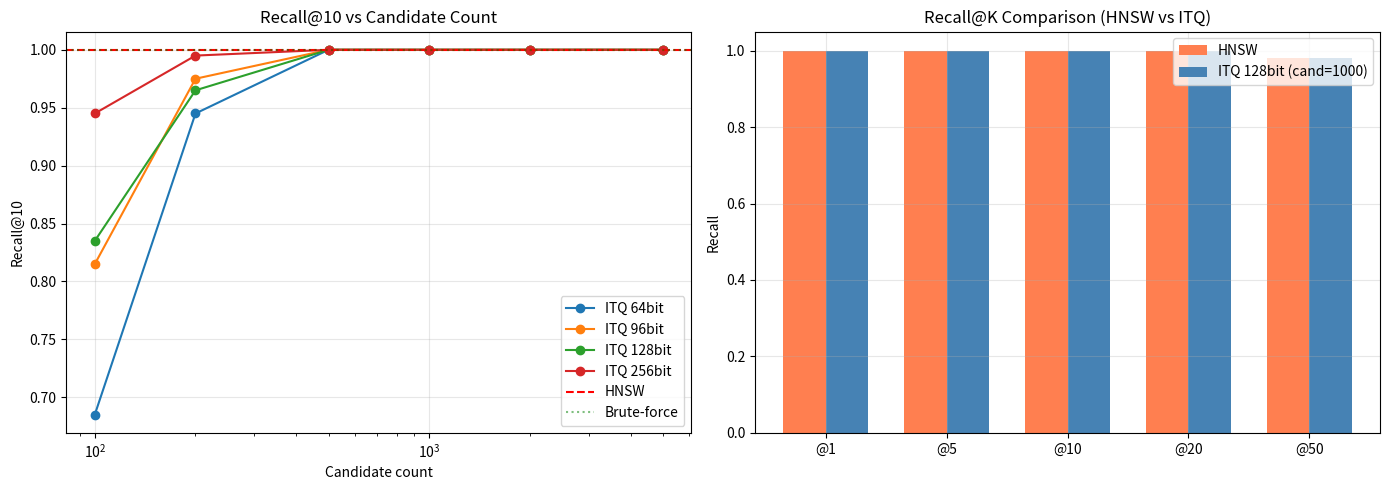

In [6]:
# Recall@10 vs 候補数のプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Recall@10 vs 候補数（ビット数別）
for n_bits in BIT_COUNTS:
    recalls = []
    cands = []
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        if key in cascade_metrics:
            recalls.append(cascade_metrics[key]["Recall@10"])
            cands.append(candidates)
    if recalls:
        axes[0].plot(cands, recalls, "o-", label=f"ITQ {n_bits}bit")

axes[0].axhline(y=hnsw_metrics["Recall@10"], color="red", linestyle="--", label="HNSW")
axes[0].axhline(y=1.0, color="green", linestyle=":", alpha=0.5, label="Brute-force")
axes[0].set_xlabel("Candidate count")
axes[0].set_ylabel("Recall@10")
axes[0].set_title("Recall@10 vs Candidate Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

# (b) Recall@K 比較（128bit, candidates=1000）
key_128_1000 = (128, 1000)
if key_128_1000 in cascade_metrics:
    k_values_plot = [k for k in TOP_K_VALUES]
    hnsw_recalls = [hnsw_metrics.get(f"Recall@{k}", 0) for k in k_values_plot]
    itq_recalls = [cascade_metrics[key_128_1000].get(f"Recall@{k}", 0) for k in k_values_plot]
    
    x = np.arange(len(k_values_plot))
    w = 0.35
    axes[1].bar(x - w/2, hnsw_recalls, w, label="HNSW", color="coral")
    axes[1].bar(x + w/2, itq_recalls, w, label="ITQ 128bit (cand=1000)", color="steelblue")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"@{k}" for k in k_values_plot])
    axes[1].set_ylabel("Recall")
    axes[1].set_title("Recall@K Comparison (HNSW vs ITQ)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 6. Top-10 結果比較

In [7]:
# 最初の3クエリで Top-10 結果を比較
for qi in range(min(3, len(query_embeddings))):
    print(f"\n{'='*60}")
    print(f"Query {qi}: {query_face_ids[qi]}")
    print(f"{'='*60}")
    
    gt_fids = ground_truth[qi]["face_ids"][:10]
    gt_scores = ground_truth[qi]["scores"][:10]
    
    print(f"\n{'Rank':>4} | {'Brute-force':>36} | {'Score':>6} | {'HNSW':>36} | {'ITQ(128,1000)':>36}")
    print("-" * 130)
    
    hnsw_fids = hnsw_results[qi][:10]
    itq_key = (128, 1000)
    itq_fids = cascade_results.get(itq_key, {}).get(qi, [])[:10]
    
    for rank in range(10):
        gt_fid = gt_fids[rank] if rank < len(gt_fids) else "-"
        gt_sc = f"{gt_scores[rank]:.4f}" if rank < len(gt_scores) else "-"
        h_fid = hnsw_fids[rank] if rank < len(hnsw_fids) else "-"
        h_match = "✓" if h_fid == gt_fid else " "
        i_fid = itq_fids[rank] if rank < len(itq_fids) else "-"
        i_match = "✓" if i_fid == gt_fid else " "
        print(f"{rank+1:4d} | {str(gt_fid):>36} | {gt_sc:>6} | {h_match}{str(h_fid):>35} | {i_match}{str(i_fid):>35}")


Query 0: 007d42bd-8f54-4eaf-89f7-675ed1c81b0a

Rank |                          Brute-force |  Score |                                 HNSW |                        ITQ(128,1000)
----------------------------------------------------------------------------------------------------------------------------------
   1 | 66b0b65f-e3b7-4514-a7ee-d30695dcb309 | 0.8454 | ✓66b0b65f-e3b7-4514-a7ee-d30695dcb309 | ✓66b0b65f-e3b7-4514-a7ee-d30695dcb309
   2 | 485820e3-999e-4627-b72f-a0f109892fa9 | 0.8450 | ✓485820e3-999e-4627-b72f-a0f109892fa9 | ✓485820e3-999e-4627-b72f-a0f109892fa9
   3 | 8b567879-e047-426b-8fc0-2b44bfc8312f | 0.8396 | ✓8b567879-e047-426b-8fc0-2b44bfc8312f | ✓8b567879-e047-426b-8fc0-2b44bfc8312f
   4 | 3bc855a7-3337-48f8-8ea2-e9390fe04cee | 0.8317 | ✓3bc855a7-3337-48f8-8ea2-e9390fe04cee | ✓3bc855a7-3337-48f8-8ea2-e9390fe04cee
   5 | d263b837-d530-4a4c-a7fd-3abdcbe5d020 | 0.8275 | ✓d263b837-d530-4a4c-a7fd-3abdcbe5d020 | ✓d263b837-d530-4a4c-a7fd-3abdcbe5d020
   6 | 965bbc7f-90c8-4021

## 7. サマリー

In [8]:
# サマリーテーブル
print("=" * 60)
print("カスケード検索精度評価サマリー")
print("=" * 60)

rows_data = []
rows_data.append({"method": "Brute-force", **{f"Recall@{k}": 1.0 for k in TOP_K_VALUES}, "MRR@10": 1.0})
rows_data.append({"method": "HNSW", **hnsw_metrics})

for (n_bits, candidates), m in sorted(cascade_metrics.items()):
    rows_data.append({"method": f"ITQ {n_bits}bit (cand={candidates})", **m})

summary_df = pd.DataFrame(rows_data).set_index("method")
print(summary_df.to_string(float_format="%.4f"))

print(f"\nHNSW mean latency: {np.mean(hnsw_times)*1000:.1f} ms")
print("\n→ NB94 で ITQ 超平面の汎化性検証へ進む")

conn.close()

カスケード検索精度評価サマリー
                        Recall@1  Recall@5  Recall@10  Recall@20  Recall@50  MRR@10
method                                                                             
Brute-force               1.0000    1.0000     1.0000     1.0000     1.0000  1.0000
HNSW                      1.0000    1.0000     1.0000     1.0000     0.9800  1.0000
ITQ 64bit (cand=100)      0.7500    0.7600     0.6850     0.6825     0.6400  0.7500
ITQ 64bit (cand=200)      0.9500    0.9600     0.9450     0.9475     0.9360  0.9500
ITQ 64bit (cand=500)      1.0000    1.0000     1.0000     1.0000     0.9800  1.0000
ITQ 64bit (cand=1000)     1.0000    1.0000     1.0000     1.0000     0.9800  1.0000
ITQ 64bit (cand=2000)     1.0000    1.0000     1.0000     1.0000     0.9800  1.0000
ITQ 64bit (cand=5000)     1.0000    1.0000     1.0000     1.0000     0.9800  1.0000
ITQ 96bit (cand=100)      0.6500    0.8400     0.8150     0.7475     0.6820  0.6500
ITQ 96bit (cand=200)      0.9000    0.9800     0.9750     0.

## 評価・考察

### HNSW
- **Recall@10 = 1.000**: 75K 規模では HNSW は完璧な精度を維持。Recall@50 で 0.980 とわずかに低下するのみ
- **レイテンシ 53ms**: DuckDB vss 経由のため SQL パース等のオーバーヘッドを含む

### ITQ-LSH カスケード検索
- **候補数 500 以上で Recall@10 = 1.000**: 全ビット数（64/96/128/256bit）で候補数500が実用的な閾値
- **候補数 200 で Recall@10 ≈ 0.95**: 速度重視でも高い精度を維持
- **候補数 100 では 0.68〜0.82**: 不十分。75K corpus に対して 100 件（0.13%）では真の近傍を取りこぼす

### 重要な発見
- **顔埋め込みは検索が「容易」**: 同一人物の類似度が 0.7 程度と高く、ランダムペアの 0.05 から大きく離れているため、ハミング距離による粗いフィルタリングでも高い再現率を達成
- **NB92 での Spearman ρ が 0.5〜0.6 でも Recall@10 は 1.000**: カスケード戦略（ハミング距離で候補選択→コサイン類似度でリランキング）が効果的に機能
- **ビット数の影響は小さい**: 64bit でも候補数を十分に取れば 128bit と同等。ビット数はむしろバンドインデックスの設計に影響する

### 推奨
- 候補数 500 を基準とし、速度要件に応じて 200〜1000 の範囲で調整
- 128bit を採用し、NB95/96 の Overlap/Pivot による候補削減を検討